In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
dfn = pd.read_excel('practiceset2.xlsx')

In [8]:
dfn.drop(['Unnamed: 0','year','month'],axis=1,inplace=True)
dfn.head()

,interest_rate,unemployment_rate,index_prices
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [9]:
dfn.corr()

,interest_rate,unemployment_rate,index_prices
interest_rate,1.000000,-0.925857,0.914234
unemployment_rate,-0.925857,1.000000,-0.922338
index_prices,0.914234,-0.922338,1.000000


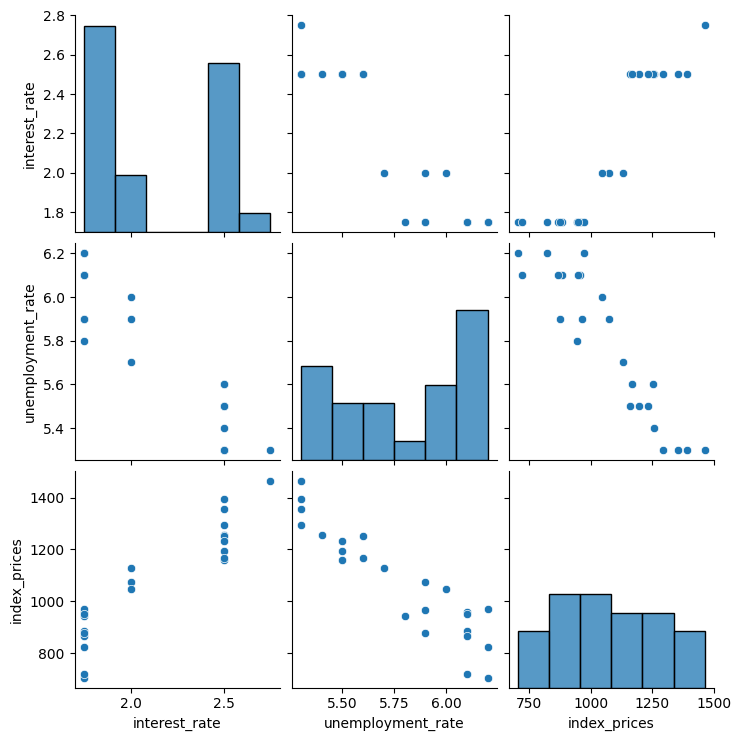

In [11]:
import seaborn as sns
sns.pairplot(dfn)


In [ ]:
## INDEPENDENT AND DEPENDENT FEATURES
X = dfn[['interest_rate','unemployment_rate']]
y = dfn['index_prices']

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

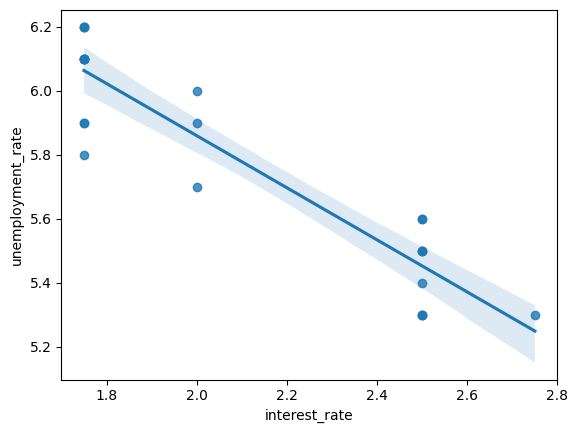

In [ ]:
sns.regplot(x = dfn['interest_rate'],y = dfn['unemployment_rate'])
## similiarly for other features we can do 

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [30]:
X_train

array([[-0.90844538,  0.37908503],
       [ 1.22442638, -1.48187786],
       [-0.90844538,  1.30956648],
       [ 1.22442638, -0.55139641],
       [ 1.22442638, -1.48187786],
       [-0.19748813,  0.68924552],
       [-0.90844538,  0.999406  ],
       [ 1.22442638, -1.48187786],
       [ 1.22442638, -1.17171738],
       [-0.90844538,  1.30956648],
       [-0.90844538,  0.999406  ],
       [-0.90844538,  0.37908503],
       [-0.90844538,  0.999406  ],
       [ 1.22442638, -0.8615569 ],
       [-0.19748813, -0.24123593],
       [-0.90844538,  0.06892455],
       [-0.90844538,  0.999406  ],
       [ 1.22442638, -0.8615569 ]])

In [22]:
from sklearn.linear_model import LinearRegression
regresser = LinearRegression()
regresser.fit(X_train,y_train)

LinearRegression()

## Cross validation 


In [33]:
from sklearn.model_selection import cross_val_score
val_score = cross_val_score(regresser,X_train,y_train,scoring='neg_mean_squared_error',cv = 3)


In [34]:
np.mean(val_score)

np.float64(-6398.7583900430045)

In [35]:
## prediction 
y_pred = regresser.predict(X_test)
## performance matrices
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse,rmse,mae)

8140.231303005178 90.2232303955316 81.22154343093892


In [36]:
## R score 
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)
## that is 73 %

0.758196586836688


In [37]:
# Adjuested R-score
## In the formula for Adjusted R², 
# the value of N (number of observations) should be the length of the test dataset 
# when evaluating model performance on the test set.
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_train.shape[1]-1)

0.59699431139448

## Assumptions

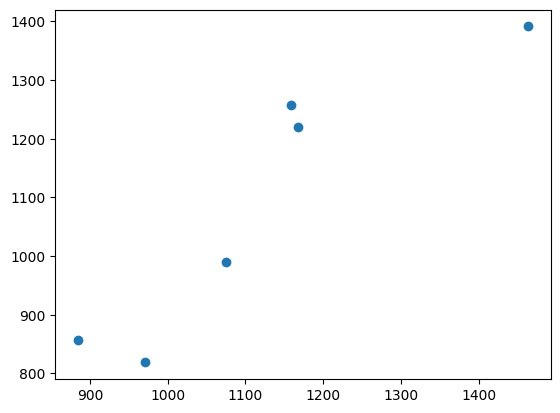

In [38]:
plt.scatter(y_test,y_pred)

In [39]:
residuals = y_test-y_pred
print(residuals)

8     -98.711081
16    152.464504
0      72.753002
18     26.896672
11     84.360754
9     -52.143248
Name: index_prices, dtype: float64


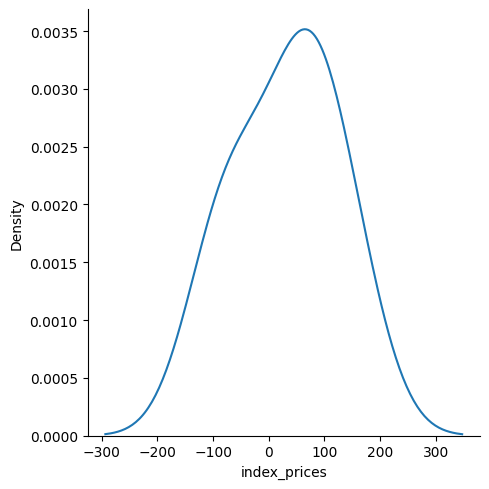

In [40]:
## plot residuals
sns.displot(residuals,kind='kde')